KNN (K-Nearest Neighbors)

Not because it's the most powerful, but because it teaches a very important ML concept:

Distance-Based Learning

End-to-End Project Idea

Use a completely new business case:

An e-commerce company wants to predict whether a customer will purchase a product after visiting the website.

Customer Purchase Prediction:

target:
0 = Will Not Purchase
1 = Will Purchase

features:
Age
AnnualIncome
WebsiteVisits
TimeSpentOnSite
PreviousPurchases


Why KNN? Similar customers behave similarly.

New Customer
     ↓
Find nearest customers
     ↓
Check their purchases
     ↓
Majority vote
     ↓
Predict

Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

Generate dataset

In [2]:
np.random.seed(42)

n = 5000

age = np.random.randint(18, 70, n)

annual_income = np.random.randint(20000, 200000, n)

website_visits = np.random.randint(1, 50, n)

time_on_site = np.random.randint(1, 60, n)

previous_purchases = np.random.randint(0, 20, n)

purchase = (
    (annual_income > 70000).astype(int)
    + (website_visits > 15).astype(int)
    + (time_on_site > 20).astype(int)
    + (previous_purchases > 5).astype(int)
)

purchase = (purchase >= 3).astype(int)

df = pd.DataFrame({
    "Age": age,
    "AnnualIncome": annual_income,
    "WebsiteVisits": website_visits,
    "TimeOnSite": time_on_site,
    "PreviousPurchases": previous_purchases,
    "Purchase": purchase
})

df.head()

,Age,AnnualIncome,WebsiteVisits,TimeOnSite,PreviousPurchases,Purchase
0,56,21920,1,37,13,0
1,69,126121,9,7,2,0
2,46,96872,20,20,15,1
3,32,101132,19,34,14,1
4,60,22093,36,35,6,1


EDA

In [7]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Purchase"].value_counts())

print("\nSummary Statistics:")
print(df.describe())

Shape: (5000, 6)

Missing Values:
Age                  0
AnnualIncome         0
WebsiteVisits        0
TimeOnSite           0
PreviousPurchases    0
Purchase             0
dtype: int64

Target Distribution:
Purchase
1    3171
0    1829
Name: count, dtype: int64

Summary Statistics:
               Age   AnnualIncome  WebsiteVisits  TimeOnSite  \
count  5000.000000    5000.000000    5000.000000  5000.00000   
mean     43.584600  110220.247000      24.724400    29.95640   
std      14.919094   52075.384023      14.103086    16.99303   
min      18.000000   20028.000000       1.000000     1.00000   
25%      31.000000   64751.000000      13.000000    15.00000   
50%      43.000000  110180.500000      24.000000    30.00000   
75%      56.000000  155749.750000      37.000000    45.00000   
max      69.000000  199992.000000      49.000000    59.00000   

       PreviousPurchases     Purchase  
count        5000.000000  5000.000000  
mean            9.543800     0.634200  
std             5.75

Cell 4: Target Distribution

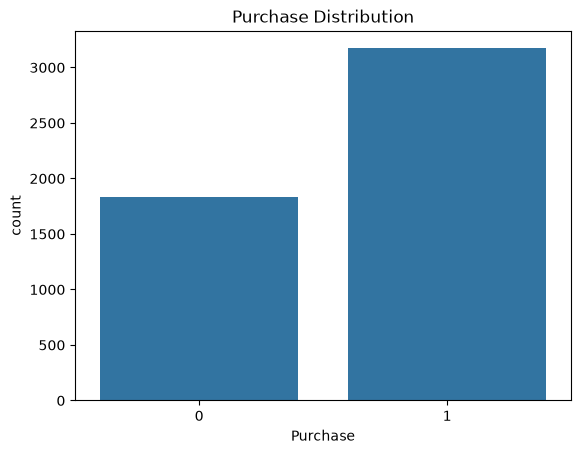

In [8]:
sns.countplot(
    data=df,
    x="Purchase"
)

plt.title("Purchase Distribution")
plt.show()

Cell 5: Correlation Heatmap

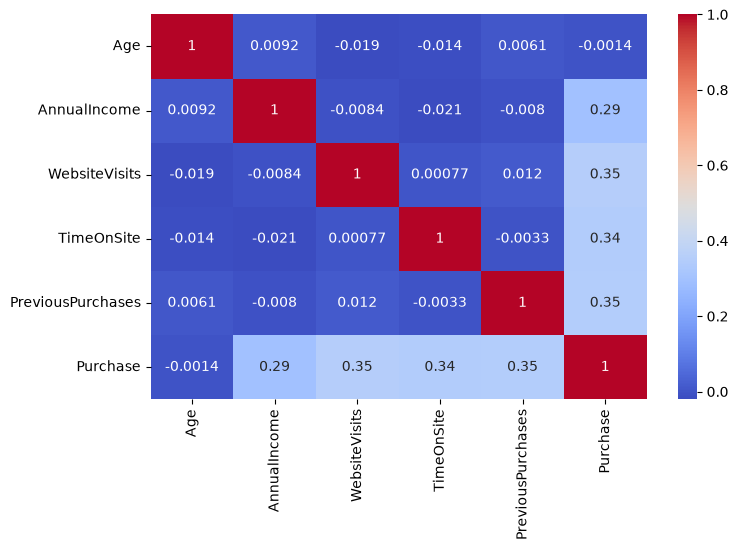

In [9]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Cell 6: Features and Target

In [12]:
X = df.drop("Purchase", axis=1)

y = df["Purchase"]

print("X:\n",X)
print("y:\n",y)

X:
       Age  AnnualIncome  WebsiteVisits  TimeOnSite  PreviousPurchases
0      56         21920              1          37                 13
1      69        126121              9           7                  2
2      46         96872             20          20                 15
3      32        101132             19          34                 14
4      60         22093             36          35                  6
...   ...           ...            ...         ...                ...
4995   24        169594             43          46                 11
4996   66        162728              2           8                  3
4997   26        166965             15          21                  2
4998   53         36493             39          53                  5
4999   36        154704             41          58                 15

[5000 rows x 5 columns]
y:
 0       0
1       0
2       1
3       1
4       1
       ..
4995    1
4996    0
4997    0
4998    0
4999    1
Name: Purchase, L

Cell 7: Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Cell 8: Feature Scaling

Very Important

KNN uses distances.

Without scaling:

Income = 100000
Age = 25

Income dominates the distance calculation

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Cell 9: Train Initial KNN Model

In [15]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Cell 10: Predictions

In [16]:
y_pred = knn.predict(
    X_test_scaled
)

y_prob = knn.predict_proba(
    X_test_scaled
)[:,1]

Cell 11: Evaluation Metrics

In [ ]:
print("Accuracy :",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall   :",
      recall_score(y_test, y_pred))

print("F1 Score :",
      f1_score(y_test, y_pred))

Cell 12: Confusion Matrix

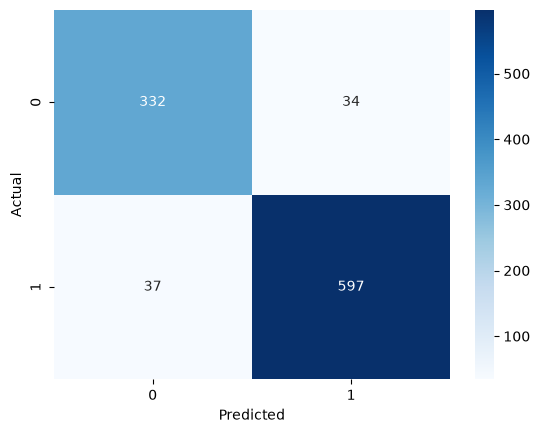

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Cell 13: Classification Report

In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       366
           1       0.95      0.94      0.94       634

    accuracy                           0.93      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.93      0.93      0.93      1000



Cell 14: Find Best K

One of the most important KNN steps.

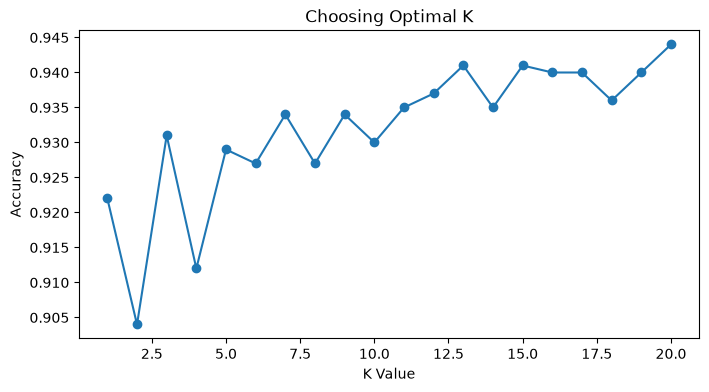

In [19]:
scores = []

for k in range(1,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    scores.append(
        model.score(
            X_test_scaled,
            y_test
        )
    )

plt.figure(figsize=(8,4))

plt.plot(
    range(1,21),
    scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("Choosing Optimal K")

plt.show()

Cell 15: Hyperparameter Tuning

In [20]:
params = {
    "n_neighbors":[3,5,7,9,11],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}


Cell 16: Best Model

In [21]:
best_knn = grid.best_estimator_

y_pred_best = best_knn.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       366
           1       0.95      0.96      0.95       634

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



Cell 17: Check Overfitting

In [22]:
print(
    "Train Score:",
    best_knn.score(
        X_train_scaled,
        y_train
    )
)

print(
    "Test Score:",
    best_knn.score(
        X_test_scaled,
        y_test
    )
)

Train Score: 1.0
Test Score: 0.942


Cell 18: Predict New Customer

In [24]:
new_customer = pd.DataFrame({
    "Age": [32],
    "AnnualIncome": [90000],
    "WebsiteVisits": [25],
    "TimeOnSite": [35],
    "PreviousPurchases": [8]
})

new_customer_scaled = scaler.transform(
    new_customer
)

prediction = best_knn.predict(
    new_customer_scaled
)

probability = best_knn.predict_proba(
    new_customer_scaled
)

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: 1
Probability: [0. 1.]
